# Stage 2 — Grid-Level Flood Loss Modeling & Uninsured Loss Estimation
**Course:** DATA 543 — Risk, Data Science, and AI  
**Study Area:** 5 Eastern NC Counties — Beaufort, Edgecombe, Lenoir, Robeson, Wayne  
**Events:** 7 hurricanes, 1996–2018  

---

## Two-Stage Modeling Framework

| Stage | Unit of Analysis | Data | Target |
|-------|-----------------|------|--------|
| **Stage 1** (prior notebook) | Individual building | FEMA NFIP Claims (11,353 rows) | `amountPaidOnBuildingClaim` |
| **Stage 2** (this notebook) | 0.1° × 0.1° grid cell (~11 km) | Aggregated grid dataset (220 rows) | `loss_ratio` = NFIP payout / insured building value |

Both stages draw from the same underlying data source (FEMA NFIP claims + NC Buildings footprints),  
but operate at different spatial resolutions. Stage 2 enables event-level and county-level uninsured loss estimation.

## Research Questions
1. What building and flood characteristics drive grid-level loss ratios in Eastern NC?
2. How much total flood loss goes uninsured, and does this vary by storm, county, or time period?

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded.')

Libraries loaded.


## Step 2 — Load Data

In [2]:
#---
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (220, 30)
Columns: ['grid_id', 'n_claims', 'total_paid', 'total_bldg_val', 'event_name', 'year', 'event_num', 'no_bldAll_flooded', 'areaSqKm_developed', 'areaSqKm_total', 'grid_lat', 'grid_lon', 'county', 'n_buildings', 'mean_elevation', 'median_elevation', 'mean_found_ht', 'mean_bldg_value', 'median_bldg_value', 'total_bldg_value', 'mean_sqft', 'mean_age', 'res_ratio', 'pct_miss_elev', 'pct_miss_value', 'area_sqkm', 'bldg_density', 'value_outlier', 'loss_ratio', 'log_total_paid']


,grid_id,n_claims,total_paid,total_bldg_val,event_name,year,event_num,no_bldAll_flooded,areaSqKm_developed,areaSqKm_total,...,mean_sqft,mean_age,res_ratio,pct_miss_elev,pct_miss_value,area_sqkm,bldg_density,value_outlier,loss_ratio,log_total_paid
0,34.4_-79.0,38,1346442.2100,4915906.0000,Hurricane Florence,2018,1,29952.0000,119.1564,2812.0536,...,1650.1149,29.6751,0.9665,0.0000,0.0183,123.2100,2.6621,False,0.2739,14.1130
1,34.4_-79.1,3,97282.0800,397120.0000,Hurricane Florence,2018,1,29952.0000,119.1564,2812.0536,...,2089.1445,38.7701,0.9619,0.0000,0.0000,123.2100,16.6220,False,0.2450,11.4854
2,34.4_-79.2,1,24763.3600,406463.0000,Hurricane Florence,2018,1,29952.0000,119.1564,2812.0536,...,2668.4373,35.1339,0.9430,0.0000,0.0000,123.2100,22.6443,False,0.0609,10.1172


## Step 3 — Descriptive Analysis

Before modeling, we characterize the distribution of `loss_ratio` across storms, counties, and time.

In [3]:
# ── Summary by storm ──────
storm_summary = (
    df.groupby(['event_name', 'year'])
    .agg(
        grid_cells        = ('grid_id',           'count'),
        total_nfip_paid_M = ('total_paid',         lambda x: x.sum() / 1e6),
        mean_loss_ratio   = ('loss_ratio',         'mean'),
        std_loss_ratio    = ('loss_ratio',         'std'),
        mean_flooded_bldgs= ('no_bldAll_flooded',  'mean'),
        total_claims      = ('n_claims',           'sum'),
    )
    .round(3)
    .sort_values('year')
)
print('=== Storm-level Summary ===')
storm_summary

=== Storm-level Summary ===


,,grid_cells,total_nfip_paid_M,mean_loss_ratio,std_loss_ratio,mean_flooded_bldgs,total_claims
event_name,year,,,,,,
Hurricane Fran,1996,30,13.4820,0.1390,0.0990,11818.0000,1019
Hurricane Bonnie,1998,19,7.5160,0.0770,0.0470,1541.0000,958
Hurricane Floyd,1999,43,34.9660,0.2390,0.2100,18051.0000,1750
Hurricane Isabel,2003,20,4.1760,0.0680,0.0610,7739.0000,593
Hurricane Irene,2011,23,30.5570,0.1120,0.0840,7553.0000,1431
Hurricane Matthew,2016,43,79.5380,0.1950,0.1230,14177.0000,1451
Hurricane Florence,2018,42,58.9800,0.1330,0.1080,29952.0000,1993


In [4]:
# ── Summary by county ───────
county_summary = (
    df.groupby('county')
    .agg(
        n_obs           = ('grid_id',    'count'),
        mean_loss_ratio = ('loss_ratio', 'mean'),
        std_loss_ratio  = ('loss_ratio', 'std'),
        max_loss_ratio  = ('loss_ratio', 'max'),
        total_paid_M    = ('total_paid', lambda x: x.sum() / 1e6),
    )
    .round(3)
    .sort_values('mean_loss_ratio', ascending=False)
)
print('=== County-level Summary ===')
county_summary

=== County-level Summary ===


,n_obs,mean_loss_ratio,std_loss_ratio,max_loss_ratio,total_paid_M
county,,,,,
Wayne,25,0.2520,0.1630,0.4750,35.9670
Lenoir,26,0.2090,0.1980,0.7260,39.5010
Edgecombe,33,0.1990,0.1870,0.6680,23.7950
Robeson,29,0.1660,0.1180,0.4730,45.2910
Beaufort,107,0.1000,0.0620,0.3050,84.6610


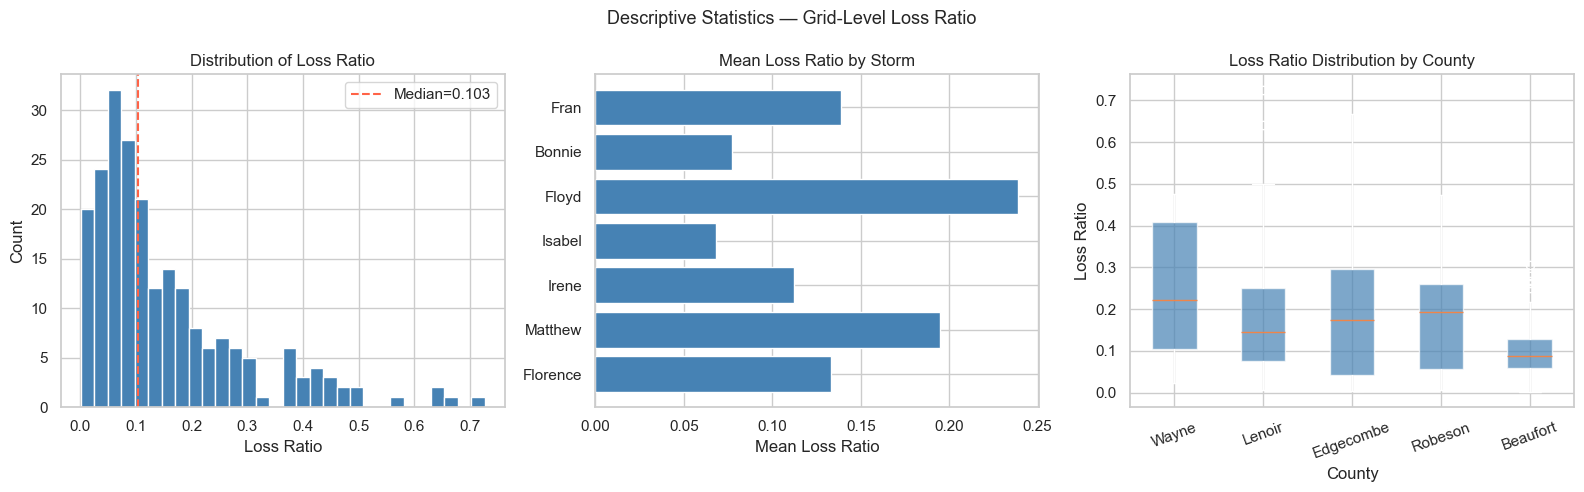

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Descriptive Statistics — Grid-Level Loss Ratio', fontsize=13)

# 1. Distribution of loss_ratio
axes[0].hist(df['loss_ratio'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['loss_ratio'].median(), color='tomato', linestyle='--', label=f'Median={df["loss_ratio"].median():.3f}')
axes[0].set_xlabel('Loss Ratio')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Loss Ratio')
axes[0].legend()

# 2. Mean loss_ratio by storm (ordered by year)
storm_order = storm_summary.reset_index().sort_values('year')['event_name'].str.replace('Hurricane ','')
mean_lr     = storm_summary.reset_index().sort_values('year')['mean_loss_ratio']
axes[1].barh(storm_order, mean_lr, color='steelblue')
axes[1].set_xlabel('Mean Loss Ratio')
axes[1].set_title('Mean Loss Ratio by Storm')
axes[1].invert_yaxis()

# 3. Boxplot by county
county_order = county_summary.index.tolist()
df_box = [df[df['county'] == c]['loss_ratio'].values for c in county_order]
bp = axes[2].boxplot(df_box, labels=county_order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
axes[2].set_xlabel('County')
axes[2].set_ylabel('Loss Ratio')
axes[2].set_title('Loss Ratio Distribution by County')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

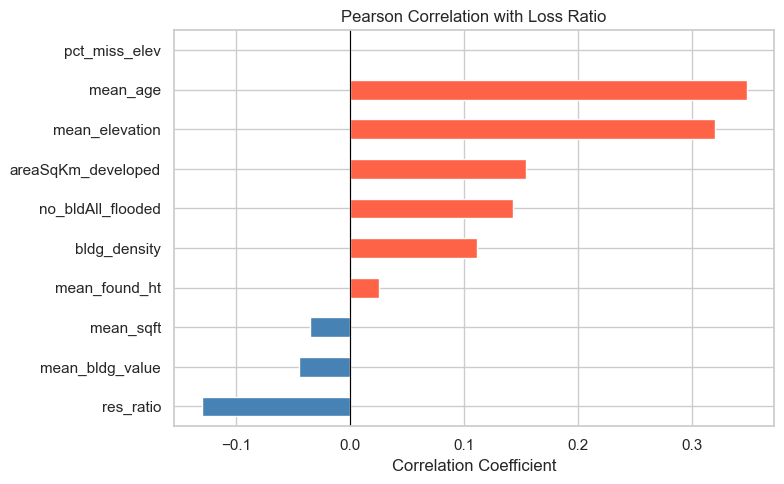


Key observations:
  Strongest positive: mean_age (r=0.348) — older buildings suffer more
  mean_elevation (r=0.320) — counter-intuitive, warrants investigation
  res_ratio (r=-0.131) — residential areas sustain relatively less loss


In [6]:
# ── Correlation with loss_ratio ────
FEATURE_COLS = [
    'no_bldAll_flooded', 'mean_elevation', 'mean_age', 'res_ratio',
    'bldg_density', 'mean_bldg_value', 'mean_sqft', 'mean_found_ht',
    'areaSqKm_developed', 'pct_miss_elev'
]

corr = df[FEATURE_COLS + ['loss_ratio']].corr()['loss_ratio'].drop('loss_ratio').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Loss Ratio')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print('\nKey observations:')
print(f'  Strongest positive: mean_age (r={corr["mean_age"]:.3f}) — older buildings suffer more')
print(f'  mean_elevation (r={corr["mean_elevation"]:.3f}) — counter-intuitive, warrants investigation')
print(f'  res_ratio (r={corr["res_ratio"]:.3f}) — residential areas sustain relatively less loss')

## Step 4 — Feature Engineering & Model Preparation

In [7]:
# ── Feature matrix ────
FEATURES = [
    'no_bldAll_flooded',   # flood exposure — flooded buildings in county-event
    'mean_elevation',      # average building elevation in cell
    'mean_age',            # average building age
    'res_ratio',           # fraction of residential buildings
    'bldg_density',        # buildings per sq km
    'mean_bldg_value',     # average building replacement value
    'mean_sqft',           # average heated square footage
    'mean_found_ht',       # average foundation height
    'areaSqKm_developed',  # developed land area in cell
    'pct_miss_elev',       # data quality flag
]

df_model = df[FEATURES + ['loss_ratio', 'event_name', 'county', 'year',
                           'grid_id', 'total_paid', 'total_bldg_val']].dropna(subset=FEATURES + ['loss_ratio'])

X = df_model[FEATURES].values
y = df_model['loss_ratio'].values

print(f'Model dataset: {X.shape[0]} rows × {X.shape[1]} features')
print(f'Target (loss_ratio): mean={y.mean():.4f}, std={y.std():.4f}, range=[{y.min():.4f}, {y.max():.4f}]')

# Feature descriptions for reference
feature_desc = {
    'no_bldAll_flooded':  'Flood Exposure',
    'mean_elevation':     'Mean Elevation (ft)',
    'mean_age':           'Mean Building Age (yrs)',
    'res_ratio':          'Residential Ratio',
    'bldg_density':       'Building Density (per km²)',
    'mean_bldg_value':    'Mean Building Value ($)',
    'mean_sqft':          'Mean Heated Sq Ft',
    'mean_found_ht':      'Mean Foundation Height (ft)',
    'areaSqKm_developed': 'Developed Area (km²)',
    'pct_miss_elev':      'Missing Elevation %',
}
print('\nFeature descriptions:')
for f, d in feature_desc.items():
    print(f'  {f:<22} → {d}')

Model dataset: 220 rows × 10 features
Target (loss_ratio): mean=0.1536, std=0.1388, range=[0.0016, 0.7258]

Feature descriptions:
  no_bldAll_flooded      → Flood Exposure
  mean_elevation         → Mean Elevation (ft)
  mean_age               → Mean Building Age (yrs)
  res_ratio              → Residential Ratio
  bldg_density           → Building Density (per km²)
  mean_bldg_value        → Mean Building Value ($)
  mean_sqft              → Mean Heated Sq Ft
  mean_found_ht          → Mean Foundation Height (ft)
  areaSqKm_developed     → Developed Area (km²)
  pct_miss_elev          → Missing Elevation %


## Step 5 — Model Training & Cross-Validation

We evaluate four models using 5-fold cross-validation:
- **Linear Regression** — baseline, interpretable coefficients
- **Ridge Regression** — regularized linear model, handles multicollinearity
- **Random Forest** — captures non-linear relationships, robust to outliers
- **Gradient Boosting** — sequential ensemble, typically strong on tabular data

Given n=220, we prioritize interpretability and avoid overfitting.

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                    learning_rate=0.05, random_state=42),
}

cv_results = {}
for name, model in models.items():
    r2   = cross_val_score(model, X, y, cv=kf, scoring='r2')
    rmse = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    cv_results[name] = {
        'R² Mean':  r2.mean(),
        'R² Std':   r2.std(),
        'RMSE Mean': -rmse.mean(),
        'RMSE Std':  rmse.std(),
    }

cv_df = pd.DataFrame(cv_results).T.round(4)
print('=== 5-Fold Cross-Validation Results ===')
cv_df

=== 5-Fold Cross-Validation Results ===


,R² Mean,R² Std,RMSE Mean,RMSE Std
Linear Regression,0.0204,0.0659,0.1368,0.0131
Ridge Regression,0.0739,0.0361,0.1328,0.0084
Random Forest,0.1102,0.1676,0.1289,0.0056
Gradient Boosting,-0.1474,0.3819,0.1442,0.0200


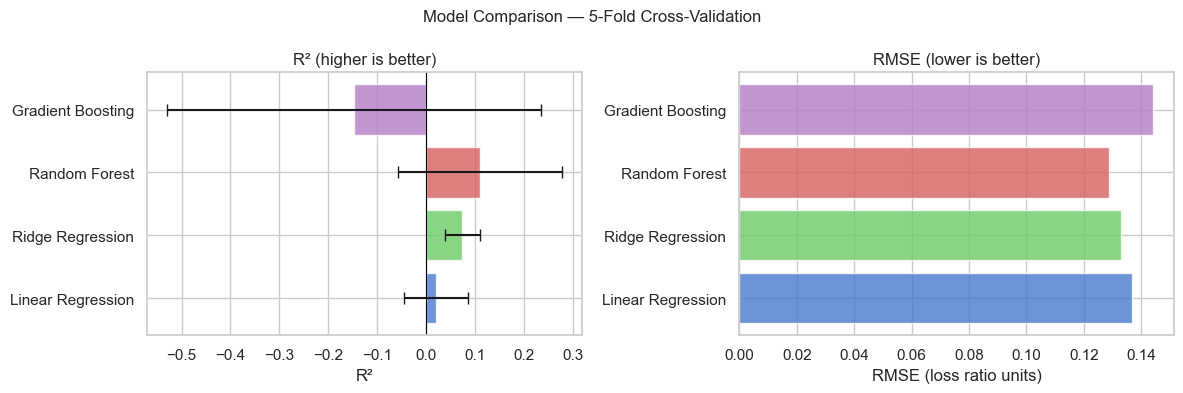


Best model by R²: Random Forest (R²=0.1102)


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Model Comparison — 5-Fold Cross-Validation', fontsize=12)

names  = list(cv_results.keys())
r2s    = [cv_results[n]['R² Mean']   for n in names]
r2stds = [cv_results[n]['R² Std']    for n in names]
rmses  = [cv_results[n]['RMSE Mean'] for n in names]

colors = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7']

ax1.barh(names, r2s, xerr=r2stds, color=colors, alpha=0.8, capsize=4)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('R²')
ax1.set_title('R² (higher is better)')

ax2.barh(names, rmses, color=colors, alpha=0.8)
ax2.set_xlabel('RMSE (loss ratio units)')
ax2.set_title('RMSE (lower is better)')

plt.tight_layout()
plt.show()

best_model_name = cv_df['R² Mean'].idxmax()
print(f'\nBest model by R²: {best_model_name} (R²={cv_df.loc[best_model_name, "R² Mean"]:.4f})')

## Step 6 — Random Forest: Feature Importance & Predictions

Random Forest is selected as the primary model for uninsured loss estimation  
due to its ability to capture non-linear interactions between building characteristics  
and flood exposure, while remaining robust to the limited sample size (n=220).

In-sample R²  : 0.6139
In-sample RMSE: 0.0862


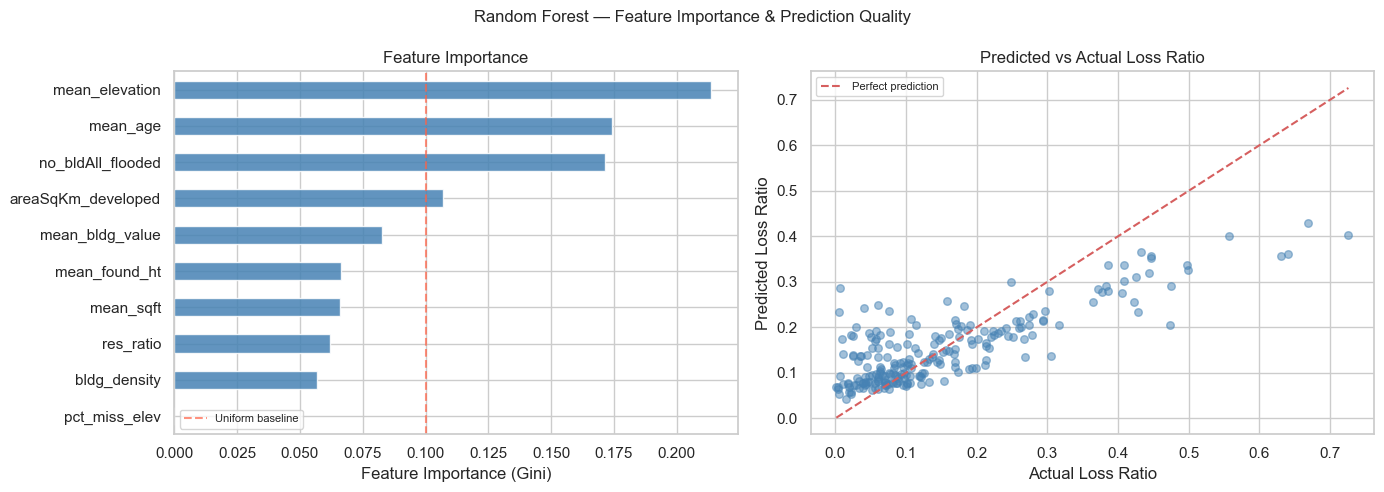


Top 3 most important features:
  mean_elevation        : 0.2136
  mean_age              : 0.1743
  no_bldAll_flooded     : 0.1713


In [10]:
# ── Fit RF on full dataset ──────
rf_final = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_final.fit(X, y)

y_pred = rf_final.predict(X)
print(f'In-sample R²  : {r2_score(y, y_pred):.4f}')
print(f'In-sample RMSE: {root_mean_squared_error(y, y_pred):.4f}')

# Feature importance
fi = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Feature Importance & Prediction Quality', fontsize=12)

# Feature importance bar
fi.plot(kind='barh', ax=ax1, color='steelblue', alpha=0.85)
ax1.set_xlabel('Feature Importance (Gini)')
ax1.set_title('Feature Importance')
ax1.axvline(1/len(FEATURES), color='tomato', linestyle='--', alpha=0.7, label='Uniform baseline')
ax1.legend(fontsize=8)

# Predicted vs actual
ax2.scatter(y, y_pred, alpha=0.5, s=30, color='steelblue')
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax2.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_xlabel('Actual Loss Ratio')
ax2.set_ylabel('Predicted Loss Ratio')
ax2.set_title('Predicted vs Actual Loss Ratio')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nTop 3 most important features:')
for feat, val in fi.sort_values(ascending=False).head(3).items():
    print(f'  {feat:<22}: {val:.4f}')

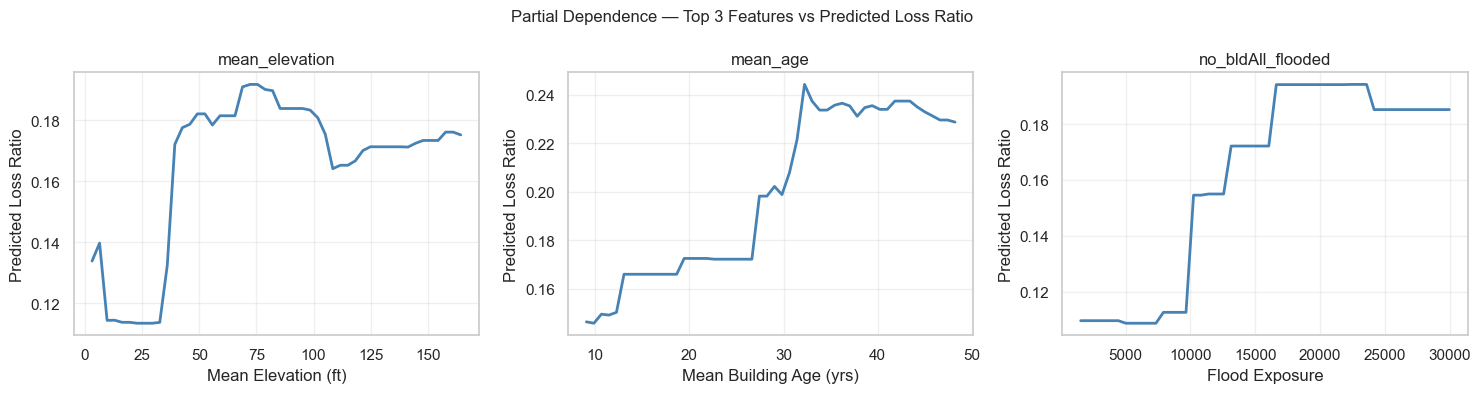

In [11]:
# ── Partial dependence plots for top 3 features ─────
top3 = fi.sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Partial Dependence — Top 3 Features vs Predicted Loss Ratio', fontsize=12)

for ax, feat in zip(axes, top3):
    feat_idx  = FEATURES.index(feat)
    feat_vals = np.linspace(df_model[feat].quantile(0.05),
                            df_model[feat].quantile(0.95), 50)
    X_temp    = np.tile(np.median(X, axis=0), (50, 1))
    X_temp[:, feat_idx] = feat_vals
    pd_preds  = rf_final.predict(X_temp)

    ax.plot(feat_vals, pd_preds, color='steelblue', linewidth=2)
    ax.set_xlabel(feature_desc.get(feat, feat))
    ax.set_ylabel('Predicted Loss Ratio')
    ax.set_title(feat)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7 — Uninsured Loss Estimation

### Methodology

The RF model predicts `loss_ratio` for each grid cell.  
We then scale this ratio to the **total** building value in the cell  
(not just insured buildings) to estimate total flood loss:

$$\text{Estimated Total Loss} = \hat{\text{loss\_ratio}} \times \text{total\_bldg\_val}$$

$$\text{Uninsured Gap} = \text{Estimated Total Loss} - \text{NFIP Actual Payout}$$

> **Note:** `total_bldg_val` (used for `loss_ratio` denominator) represents the insured building value  
> captured in FEMA claims. `total_bldg_value` (NC Buildings GDB) represents all structures.  
> The uninsured gap is therefore a **conservative lower bound** — true uninsured losses are likely higher.

In [12]:
# ── Apply model to all grid cells ──────
df_model = df_model.copy()
df_model['predicted_loss_ratio'] = rf_final.predict(X)
df_model['estimated_total_loss'] = df_model['predicted_loss_ratio'] * df_model['total_bldg_val']
df_model['uninsured_gap']        = (df_model['estimated_total_loss'] - df_model['total_paid']).clip(lower=0)
df_model['uninsured_pct']        = (
    df_model['uninsured_gap'] / df_model['estimated_total_loss'].replace(0, np.nan) * 100
).fillna(0)

print('=== Grid-level uninsured gap (sample) ===')
cols_show = ['grid_id','event_name','year','county','total_paid',
             'estimated_total_loss','uninsured_gap','uninsured_pct']
df_model[cols_show].sort_values('uninsured_gap', ascending=False).head(10).round(0)

=== Grid-level uninsured gap (sample) ===


,grid_id,event_name,year,county,total_paid,estimated_total_loss,uninsured_gap,uninsured_pct
93,35.2_-77.6,Hurricane Floyd,1999,Lenoir,7037412.0000,123106432.0000,116069020.0000,94.0000
209,35.4_-76.6,Hurricane Bonnie,1998,Beaufort,2177295.0000,94173641.0000,91996346.0000,98.0000
171,35.4_-77.1,Hurricane Fran,1996,Beaufort,1197777.0000,21857835.0000,20660058.0000,95.0000
27,35.3_-78.0,Hurricane Florence,2018,Wayne,2076274.0000,6371819.0000,4295545.0000,67.0000
4,34.5_-79.1,Hurricane Florence,2018,Robeson,1562921.0000,4720281.0000,3157361.0000,67.0000
124,35.8_-77.8,Hurricane Floyd,1999,Edgecombe,847070.0000,3483244.0000,2636174.0000,76.0000
60,35.3_-78.0,Hurricane Matthew,2016,Wayne,15430320.0000,17727377.0000,2297057.0000,13.0000
40,35.5_-77.1,Hurricane Florence,2018,Beaufort,129386.0000,1833969.0000,1704583.0000,93.0000
16,35.2_-77.6,Hurricane Florence,2018,Lenoir,6247726.0000,7680856.0000,1433130.0000,19.0000
187,35.4_-76.6,Hurricane Isabel,2003,Beaufort,1812117.0000,2584215.0000,772099.0000,30.0000


In [13]:
# ── Aggregate by storm ──────
storm_gap = (
    df_model.groupby(['event_name', 'year'])
    .agg(
        nfip_paid_M    = ('total_paid',          lambda x: x.sum() / 1e6),
        est_total_M    = ('estimated_total_loss', lambda x: x.sum() / 1e6),
        uninsured_M    = ('uninsured_gap',        lambda x: x.sum() / 1e6),
        n_grids        = ('grid_id',              'count'),
    )
    .assign(uninsured_pct = lambda x: (x['uninsured_M'] / x['est_total_M'] * 100).round(1))
    .round(2)
    .sort_values('year')
)

print('=== Uninsured Loss by Storm ===')
storm_gap

=== Uninsured Loss by Storm ===


,,nfip_paid_M,est_total_M,uninsured_M,n_grids,uninsured_pct
event_name,year,,,,,
Hurricane Fran,1996,13.4800,32.5400,20.9400,30,64.4000
Hurricane Bonnie,1998,7.5200,99.2800,92.3800,19,93.1000
Hurricane Floyd,1999,34.9700,148.9800,119.6800,43,80.3000
Hurricane Isabel,2003,4.1800,5.9100,1.8400,20,31.1000
Hurricane Irene,2011,30.5600,25.1600,0.9800,23,3.9000
Hurricane Matthew,2016,79.5400,69.6900,4.6000,43,6.6000
Hurricane Florence,2018,58.9800,62.8200,12.8200,42,20.4000


In [14]:
# ── Aggregate by county ─────
county_gap = (
    df_model.groupby('county')
    .agg(
        nfip_paid_M  = ('total_paid',          lambda x: x.sum() / 1e6),
        est_total_M  = ('estimated_total_loss', lambda x: x.sum() / 1e6),
        uninsured_M  = ('uninsured_gap',        lambda x: x.sum() / 1e6),
        n_obs        = ('grid_id',              'count'),
    )
    .assign(uninsured_pct = lambda x: (x['uninsured_M'] / x['est_total_M'] * 100).round(1))
    .round(2)
    .sort_values('uninsured_pct', ascending=False)
)

print('=== Uninsured Loss by County (across all storms) ===')
county_gap

=== Uninsured Loss by County (across all storms) ===


,nfip_paid_M,est_total_M,uninsured_M,n_obs,uninsured_pct
county,,,,,
Lenoir,39.5000,152.4600,118.2200,26,77.5000
Beaufort,84.6600,189.4800,119.8400,107,63.2000
Wayne,35.9700,39.4600,6.9500,25,17.6000
Edgecombe,23.8000,22.1200,3.8600,33,17.5000
Robeson,45.2900,40.8500,4.3600,29,10.7000


## Step 8 — Visualization of Uninsured Loss

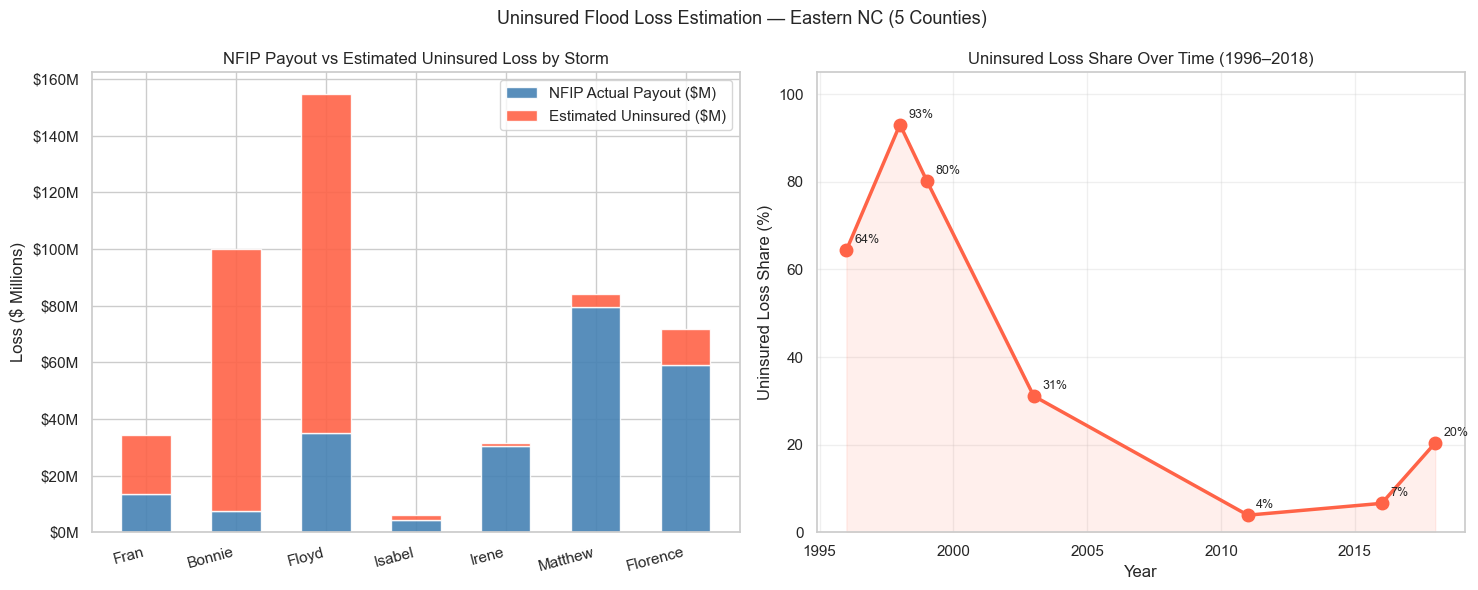

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Uninsured Flood Loss Estimation — Eastern NC (5 Counties)', fontsize=13)

sg = storm_gap.reset_index().sort_values('year')
short_names = sg['event_name'].str.replace('Hurricane ', '')
x = np.arange(len(sg))

# ── Stacked bar: NFIP paid vs uninsured ──────
axes[0].bar(x, sg['nfip_paid_M'],  0.55, label='NFIP Actual Payout ($M)',    color='steelblue', alpha=0.9)
axes[0].bar(x, sg['uninsured_M'],  0.55, label='Estimated Uninsured ($M)',   color='tomato',    alpha=0.9,
            bottom=sg['nfip_paid_M'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=15, ha='right')
axes[0].set_ylabel('Loss ($ Millions)')
axes[0].set_title('NFIP Payout vs Estimated Uninsured Loss by Storm')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))

# ── Uninsured % over time ─────
axes[1].plot(sg['year'], sg['uninsured_pct'], marker='o', color='tomato',
             linewidth=2.5, markersize=9, zorder=3)
for _, row in sg.iterrows():
    axes[1].annotate(
        f"{row['uninsured_pct']:.0f}%",
        (row['year'], row['uninsured_pct']),
        textcoords='offset points', xytext=(6, 5), fontsize=9
    )
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Uninsured Loss Share (%)')
axes[1].set_title('Uninsured Loss Share Over Time (1996–2018)')
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(sg['year'], sg['uninsured_pct'], alpha=0.1, color='tomato')

plt.tight_layout()
plt.show()

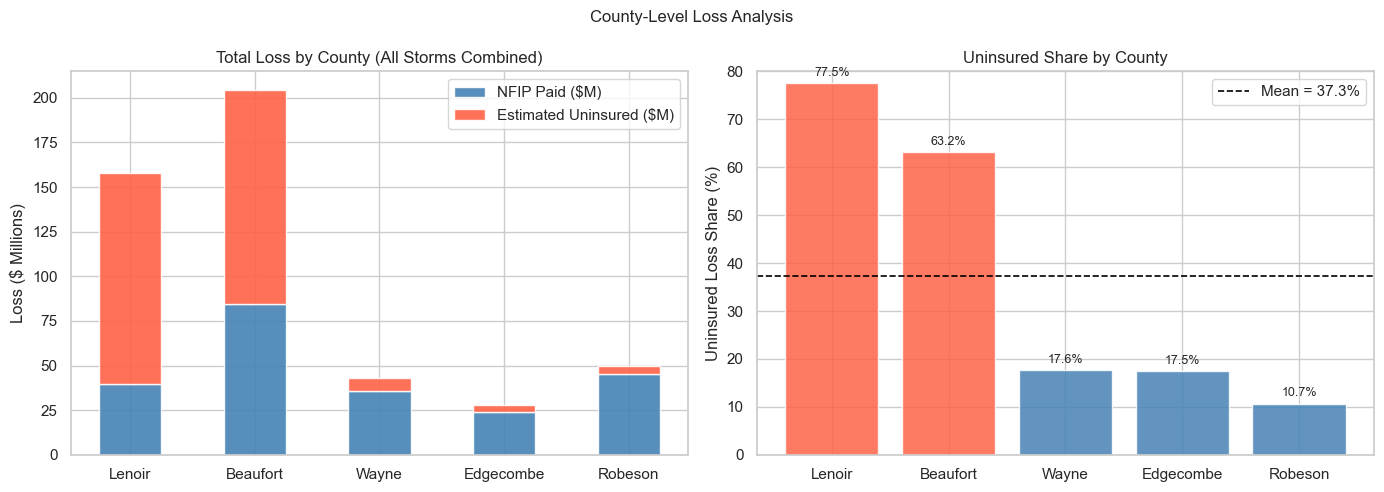

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('County-Level Loss Analysis', fontsize=12)

cg = county_gap.reset_index()

# ── Stacked bar by county ─────
x = np.arange(len(cg))
axes[0].bar(x, cg['nfip_paid_M'],  0.5, label='NFIP Paid ($M)',           color='steelblue', alpha=0.9)
axes[0].bar(x, cg['uninsured_M'],  0.5, label='Estimated Uninsured ($M)', color='tomato',    alpha=0.9,
            bottom=cg['nfip_paid_M'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(cg['county'])
axes[0].set_ylabel('Loss ($ Millions)')
axes[0].set_title('Total Loss by County (All Storms Combined)')
axes[0].legend()

# ── Uninsured % by county ─────
colors = ['tomato' if v > 30 else 'steelblue' for v in cg['uninsured_pct']]
axes[1].bar(cg['county'], cg['uninsured_pct'], color=colors, alpha=0.85)
axes[1].axhline(cg['uninsured_pct'].mean(), color='black', linestyle='--',
                linewidth=1.2, label=f"Mean = {cg['uninsured_pct'].mean():.1f}%")
axes[1].set_ylabel('Uninsured Loss Share (%)')
axes[1].set_title('Uninsured Share by County')
axes[1].set_ylim(0, 80)
axes[1].legend()
for i, (_, row) in enumerate(cg.iterrows()):
    axes[1].text(i, row['uninsured_pct'] + 1.5, f"{row['uninsured_pct']:.1f}%",
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
print('=== Predicted vs Actual loss_ratio by storm ===')
print(df_model.groupby('event_name')[['loss_ratio','predicted_loss_ratio']].mean().round(4))

print()
print('=== Residuals distribution ===')
df_model['residual'] = df_model['loss_ratio'] - df_model['predicted_loss_ratio']
print(df_model['residual'].describe().round(4))

print()
print('=== Is the model just predicting the mean? ===')
print(f'Std of actual predictions : {df_model["predicted_loss_ratio"].std():.4f}')
print(f'Std of actual loss_ratio  : {df_model["loss_ratio"].std():.4f}')
print(f'Mean of predictions       : {df_model["predicted_loss_ratio"].mean():.4f}')
print(f'Mean of actual            : {df_model["loss_ratio"].mean():.4f}')

=== Predicted vs Actual loss_ratio by storm ===
                    loss_ratio  predicted_loss_ratio
event_name                                          
Hurricane Bonnie        0.0766                0.0923
Hurricane Florence      0.1326                0.1537
Hurricane Floyd         0.2394                0.2143
Hurricane Fran          0.1390                0.1444
Hurricane Irene         0.1122                0.1017
Hurricane Isabel        0.0683                0.0919
Hurricane Matthew       0.1946                0.1838

=== Residuals distribution ===
count   220.0000
mean     -0.0002
std       0.0864
min      -0.2798
25%      -0.0432
50%      -0.0060
75%       0.0440
max       0.3229
Name: residual, dtype: float64

=== Is the model just predicting the mean? ===
Std of actual predictions : 0.0804
Std of actual loss_ratio  : 0.1391
Mean of predictions       : 0.1538
Mean of actual            : 0.1536
